In [1]:
import numpy as np
import pandas as pd

# plotting
import matplotlib.pyplot as plt
## make plots bigger
from pylab import rcParams
rcParams['figure.figsize'] = 15, 7

# metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error

# models
from tbats import TBATS
from prophet import Prophet
from pmdarima import auto_arima


def plot_results(y_to_train,
                 y_to_test, y_forecast,
                 plot_conf_int=True,
                 left_bound=None, right_bound=None):

    plt.plot(y_to_train, label='train')
    plt.plot(y_to_test, label='test')
    plt.plot(y_to_test.index, y_forecast, label='prediction')

    if plot_conf_int:
        plt.fill_between(y_to_test.index,
                         left_bound, right_bound,
                         alpha=0.23, color='grey',
                         label='intervals')
    plt.legend()
    plt.show()

## Prophet, SARIMAX, TBATS — модели для предсказания временных рядов

### 1. Задача

Рассмотрим [датасет](https://www.kaggle.com/c/demand-forecasting-kernels-only/overview) с kaggle с соревнования по прогнозированию спроса на товары.

In [2]:
data = pd.read_csv('train.csv', parse_dates=['date'])
data.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [3]:
store, item = 1,1
# Оставляем из всего датасета только строки, где store == 1 и item == 1
# То есть берём продажи одного товара в одном магазине
data = data[(data['store'] == store) & (data['item'] == item)]
# Делаем колонку date индексом датафрейма. Это нужно, потому что для временных рядов дата обычно должна быть индексом
data = data.set_index('date')
# После этого data уже не DataFrame, а Series: один временной ряд продаж
data = data['sales']

In [4]:
data

date
2013-01-01    13
2013-01-02    11
2013-01-03    14
2013-01-04    13
2013-01-05    10
              ..
2017-12-27    14
2017-12-28    19
2017-12-29    15
2017-12-30    27
2017-12-31    23
Name: sales, Length: 1826, dtype: int64

### 2. Данные
Разделим данные на train и test. test — данные за последний год.

In [5]:
test_size = 365
data_train = data.iloc[: -test_size]
data_test  = data.iloc[-test_size:]

Визуализируем данные.

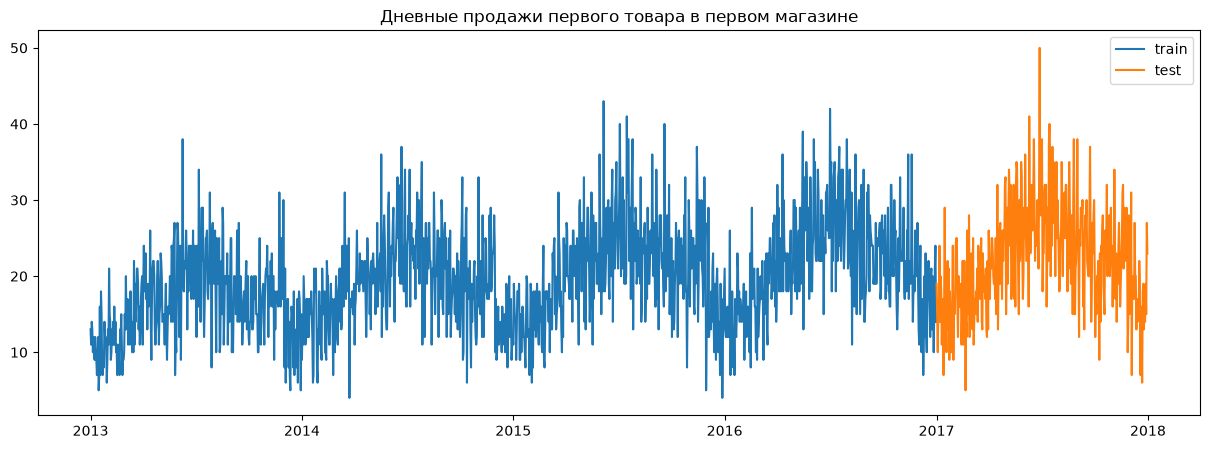

In [6]:
plt.figure(figsize=(15, 5))

plt.title('Дневные продажи первого товара в первом магазине')

plt.plot(data_train, label='train')
plt.plot(data_test, label='test')
plt.legend()

Некоторая недельная сезонность есть.

### 3. Метрики
Зададим метрики качества моделей: MSE, MAE, MAPE. Зададим функцию, которая будет вычислять метрики качества моделей и записывать их в таблицу.


- MAPE (Mean Absolute Percentage Error) поможет оценить, насколько близки прогнозы к фактическим значениям в процентном соотношении.
- 	MSE (Mean Squared Error) — для измерения среднеквадратичной ошибки между прогнозами и фактическими значениями. Это поможет понять среднюю ошибку прогноза в квадрате.
- 	MAE (Mean Absolute Error) — для оценки средней абсолютной ошибки между прогнозами и реальными значениями. Хорошо интерпретируется и проста в использовании.

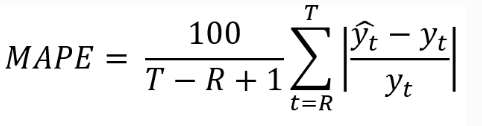

In [7]:
# MAPE
def mean_absolute_percentage_error(y_true, y_pred) -> float:
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


In [8]:
def add_method_comparison(method: str, y_true, y_forecast, compare_table=None) -> pd.DataFrame:
    result_row = {
        'method': method,
        "MSE": mean_squared_error(y_true=y_true, y_pred=y_forecast),
        "MAE": mean_absolute_error(y_true=y_true, y_pred=y_forecast),
        "MAPE": mean_absolute_percentage_error(y_true=y_true, y_pred=y_forecast)
    }

    if compare_table is None:
        compare_table = pd.DataFrame([result_row])
    else:
        if method in list(compare_table['method']):
            compare_table = compare_table[compare_table['method'] != method]

        compare_table = pd.concat([compare_table, pd.DataFrame([result_row])])
        compare_table.index = np.arange(len(compare_table))
    return compare_table



### 4. Prophet

###4.1. Prophet

Prophet — модель для предсказания временных рядов, разработанная «Фейсбуком»*.

*Деятельность компании Meta Platforms Inc., которой принадлежит указаная соцсеть и сервис, признана экстремистской и запрещена на территории РФ.

In [9]:
prophet_train_df = pd.DataFrame(data_train)
# Переименовываем колонку sales в y
prophet_train_df.columns = ['y']
# Добавляем колонку ds, в которую кладём даты из индекса
prophet_train_df['ds'] = prophet_train_df.index

Для Prophet главное, чтобы были две колонки:
ds — дата
y  — значение временного ряда

In [10]:
prophet_train_df

,y,ds
date,,
2013-01-01,13,2013-01-01
2013-01-02,11,2013-01-02
2013-01-03,14,2013-01-03
2013-01-04,13,2013-01-04
2013-01-05,10,2013-01-05
...,...,...
2016-12-27,10,2016-12-27
2016-12-28,16,2016-12-28
2016-12-29,21,2016-12-29


In [11]:
# Создаём модель Prophet; модель будет строить 95% доверительный интервал прогноза
prophet_model = Prophet(interval_width=0.95)
# Обучаем модель на подготовленном датафрейме
prophet_model.fit(prophet_train_df)
# Создаём датафрейм с будущими датами, на которые надо сделать прогноз
future = prophet_model.make_future_dataframe(
    periods=test_size, include_history=False
)
# Строим прогноз на эти будущие даты
y_prophet_forecast = prophet_model.predict(future)

11:05:46 - cmdstanpy - INFO - Chain [1] start processing
11:05:46 - cmdstanpy - INFO - Chain [1] done processing


In [12]:
y_prophet_forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2017-01-01,22.656356,12.450432,29.543134,22.656356,22.656356,-1.504734,-1.504734,-1.504734,3.723809,3.723809,3.723809,-5.228543,-5.228543,-5.228543,0.0,0.0,0.0,21.151622
1,2017-01-02,22.660401,4.708381,21.577627,22.660401,22.660401,-9.438694,-9.438694,-9.438694,-4.232952,-4.232952,-4.232952,-5.205742,-5.205742,-5.205742,0.0,0.0,0.0,13.221706
2,2017-01-03,22.664446,7.283289,24.255809,22.664439,22.664446,-6.836072,-6.836072,-6.836072,-1.636036,-1.636036,-1.636036,-5.200037,-5.200037,-5.200037,0.0,0.0,0.0,15.828373
3,2017-01-04,22.668491,8.320663,25.042197,22.668465,22.668501,-6.324847,-6.324847,-6.324847,-1.114509,-1.114509,-1.114509,-5.210337,-5.210337,-5.210337,0.0,0.0,0.0,16.343644
4,2017-01-05,22.672536,8.975061,25.190241,22.672481,22.672574,-5.942881,-5.942881,-5.942881,-0.707794,-0.707794,-0.707794,-5.235086,-5.235086,-5.235086,0.0,0.0,0.0,16.729655


ds          — дата

yhat        — прогноз продаж

yhat_lower  — нижняя граница доверительного интервала

yhat_upper  — верхняя граница доверительного интервала

trend       — оценка тренда

weekly      — недельная сезонность

yearly      — годовая сезонность

Модель для каждой даты раскладывает своё предсказание на компоненты.

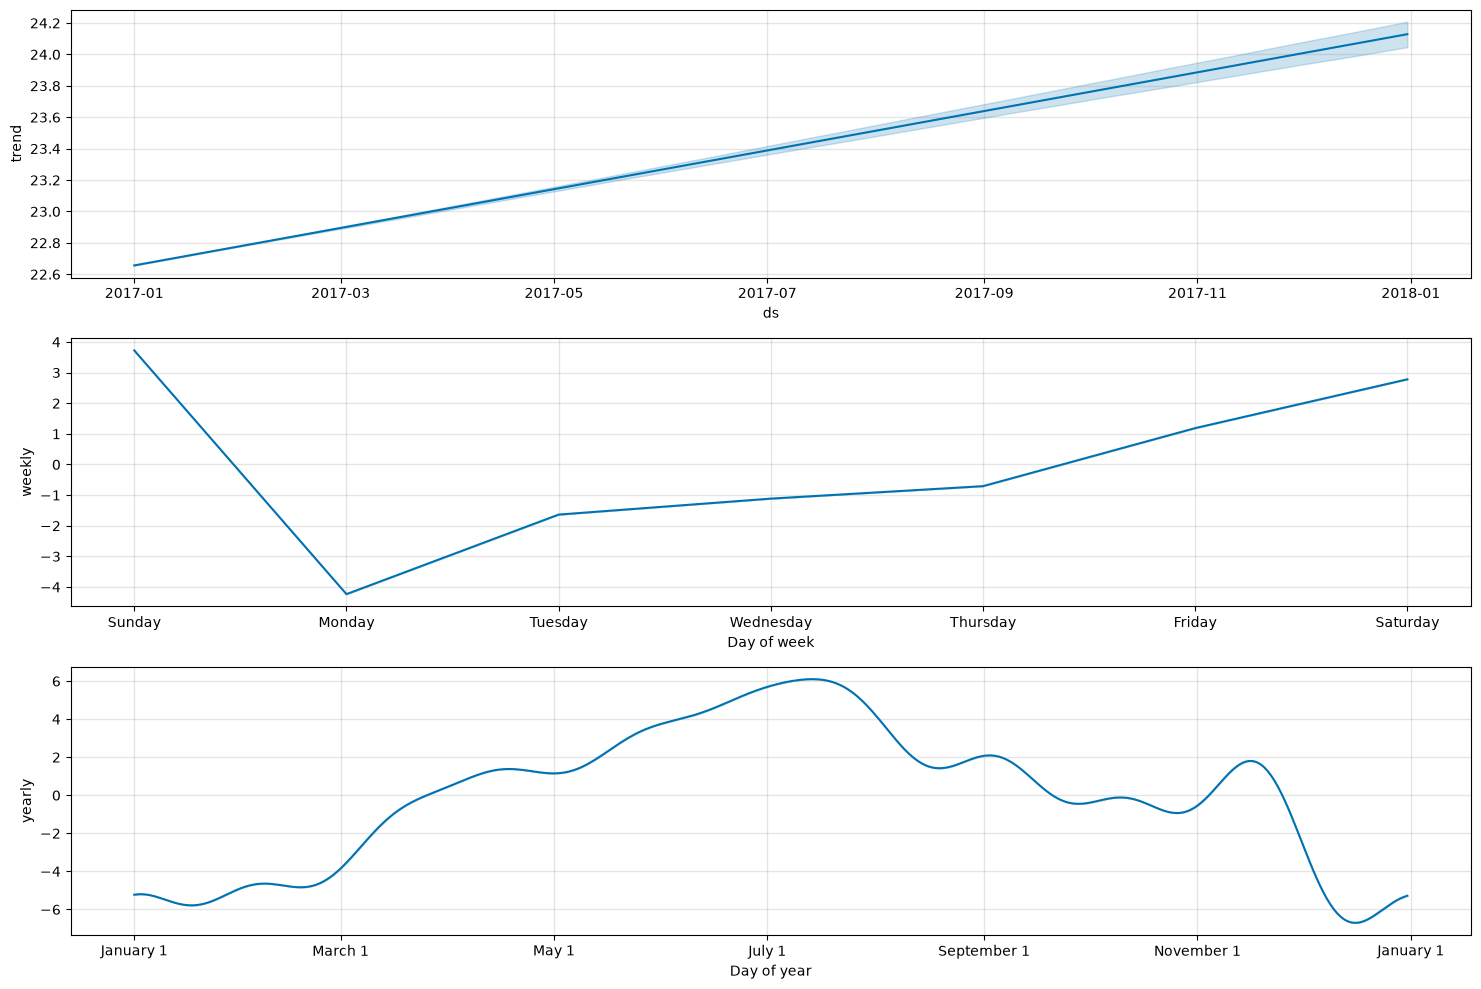

In [13]:
prophet_model.plot_components(y_prophet_forecast, figsize=(15, 10))
plt.show()

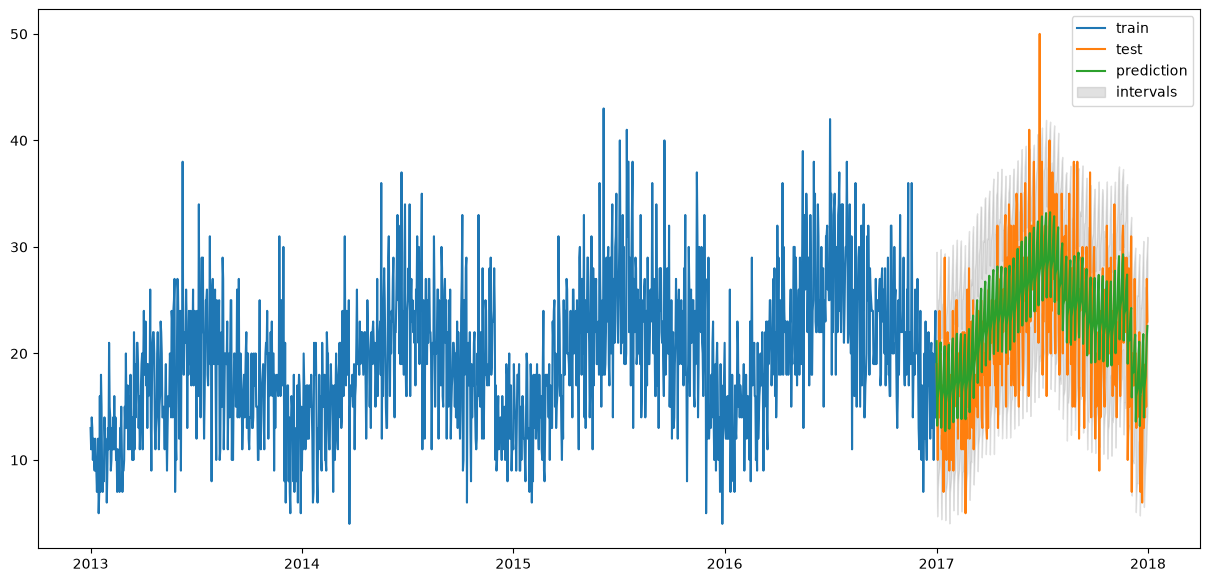

In [14]:
plot_results(data_train, data_test, y_prophet_forecast['yhat'], plot_conf_int=True,
             left_bound=y_prophet_forecast['yhat_lower'],
             right_bound=y_prophet_forecast['yhat_upper'])

In [15]:
compare_table = add_method_comparison('Prophet', data_test, y_prophet_forecast['yhat'])
compare_table

,method,MSE,MAE,MAPE
0,Prophet,24.681231,4.032162,22.234017


#### **Задание**
- Обучите модель Prophet с учётом праздников США — *Prophet + US holidays*.
- Преобразование Бокса — Кокса: обучите модель Prophet на преобразованном таргете — *Prophet*:
    - сделайте прямое преобразование над таргетом sps.boxcox(y);
    - потом сделайте обратное (нужно написать самостоятельно).

### 4.2. Prophet + US holidays

11:05:47 - cmdstanpy - INFO - Chain [1] start processing
11:05:47 - cmdstanpy - INFO - Chain [1] done processing


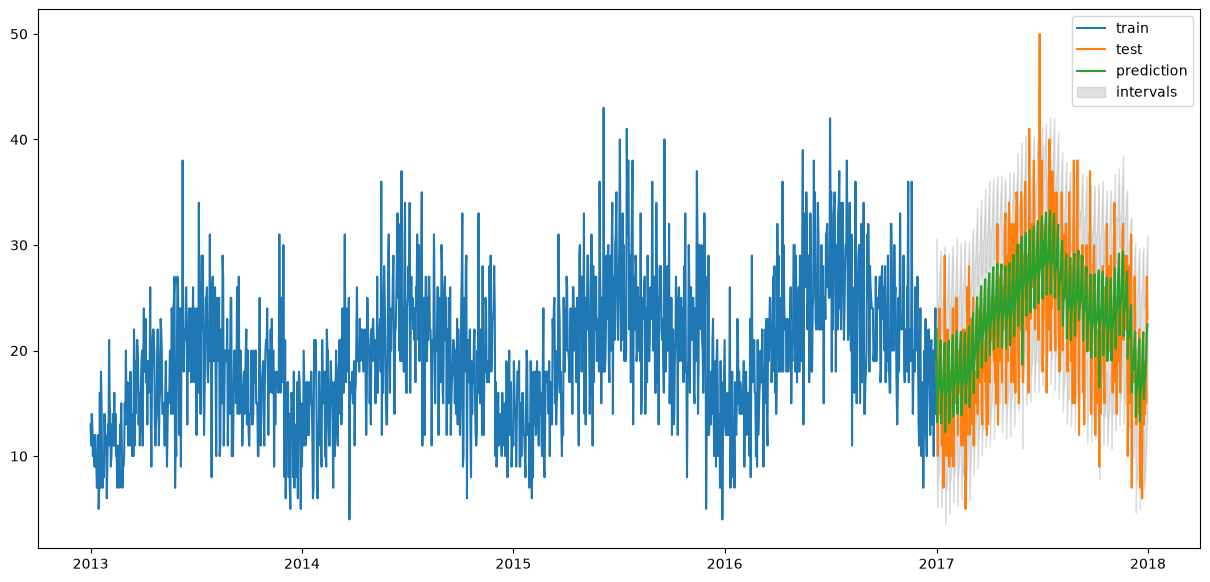

,method,MSE,MAE,MAPE
0,Prophet,24.681231,4.032162,22.234017
1,Prophet + US holidays,25.021806,4.068062,22.477414


In [16]:
#todo
# Prophet с учётом праздников США

prophet_holidays_model = Prophet(interval_width=0.95)

# Добавляем календарь государственных праздников США
# Prophet создаст дополнительные признаки для праздничных дней
prophet_holidays_model.add_country_holidays(country_name='US')

# Обучаем модель на тех же train-данных, что и обычный Prophet
prophet_holidays_model.fit(prophet_train_df)

# Создаём даты для прогноза на тестовый период
future_holidays = prophet_holidays_model.make_future_dataframe(
    periods=test_size,
    include_history=False
)

# Получаем прогноз
y_prophet_holidays_forecast = prophet_holidays_model.predict(future_holidays)

# Строим график факта и прогноза
plot_results(
    data_train,
    data_test,
    y_prophet_holidays_forecast['yhat'],
    plot_conf_int=True,
    left_bound=y_prophet_holidays_forecast['yhat_lower'],
    right_bound=y_prophet_holidays_forecast['yhat_upper']
)

# Добавляем метрики Prophet + US holidays в сравнительную таблицу
compare_table = add_method_comparison(
    'Prophet + US holidays',
    data_test,
    y_prophet_holidays_forecast['yhat'],
    compare_table
)

compare_table

### 4.3. Prophet. Преобразование Бокса — Кокса

11:05:47 - cmdstanpy - INFO - Chain [1] start processing
11:05:47 - cmdstanpy - INFO - Chain [1] done processing


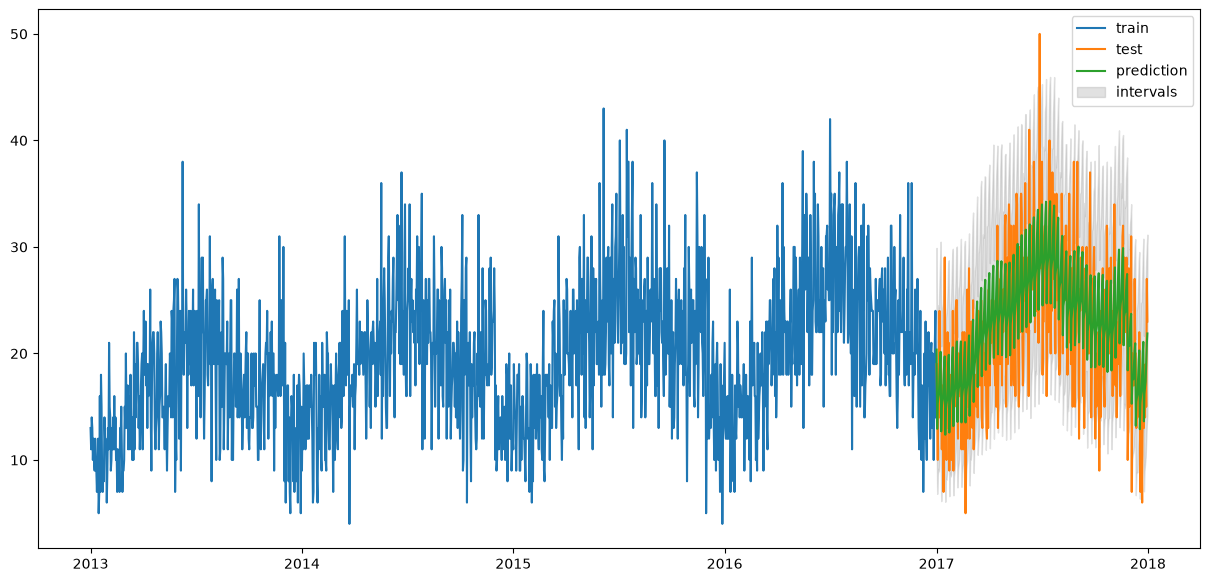

,method,MSE,MAE,MAPE
0,Prophet,24.681231,4.032162,22.234017
1,Prophet + US holidays,25.021806,4.068062,22.477414
2,Prophet + Box-Cox,24.110664,3.987201,21.678861


In [17]:
#todo
import scipy.special as sps
from scipy.stats import boxcox
# Prophet с преобразованием Бокса — Кокса

from scipy.stats import boxcox
from scipy.special import inv_boxcox

# Prophet требует датафрейм с колонками ds и y
# Поэтому создаём отдельную копию train-данных
prophet_boxcox_train_df = prophet_train_df.copy()

# Применяем преобразование Бокса — Кокса к целевой переменной y
# Функция возвращает: преобразованный ряд;
# ambda-параметр, который нужен для обратного преобразования.
prophet_boxcox_train_df['y'], fitted_lambda = boxcox(prophet_boxcox_train_df['y'])

# Создаём и обучаем Prophet на преобразованном таргете
prophet_boxcox_model = Prophet(interval_width=0.95)
prophet_boxcox_model.fit(prophet_boxcox_train_df)

# Создаём будущие даты для тестового периода
future_boxcox = prophet_boxcox_model.make_future_dataframe(
    periods=test_size,
    include_history=False
)

# Получаем прогноз в Box-Cox-шкале
y_prophet_boxcox_forecast = prophet_boxcox_model.predict(future_boxcox)

# Возвращаем прогноз из Box-Cox-шкалы обратно в исходную шкалу продаж
yhat_boxcox_inverse = inv_boxcox(
    y_prophet_boxcox_forecast['yhat'],
    fitted_lambda
)

yhat_lower_boxcox_inverse = inv_boxcox(
    y_prophet_boxcox_forecast['yhat_lower'],
    fitted_lambda
)

yhat_upper_boxcox_inverse = inv_boxcox(
    y_prophet_boxcox_forecast['yhat_upper'],
    fitted_lambda
)

# Строим график прогноза уже в исходной шкале продаж
plot_results(
    data_train,
    data_test,
    yhat_boxcox_inverse,
    plot_conf_int=True,
    left_bound=yhat_lower_boxcox_inverse,
    right_bound=yhat_upper_boxcox_inverse
)

# Добавляем метрики Prophet + Box-Cox в сравнительную таблицу
compare_table = add_method_comparison(
    'Prophet + Box-Cox',
    data_test,
    yhat_boxcox_inverse,
    compare_table
)

compare_table

In [18]:
# Подбор параметров Prophet

# Будем подбирать параметры Prophet, чтобы улучшить MAPE
# Проверяем несколько вариантов гибкости тренда и сезонности
prophet_params = [
    {
        'changepoint_prior_scale': 0.01,
        'seasonality_prior_scale': 1,
        'seasonality_mode': 'additive',
    },
    {
        'changepoint_prior_scale': 0.05,
        'seasonality_prior_scale': 10,
        'seasonality_mode': 'additive',
    },
    {
        'changepoint_prior_scale': 0.1,
        'seasonality_prior_scale': 10,
        'seasonality_mode': 'multiplicative',
    },
    {
        'changepoint_prior_scale': 0.3,
        'seasonality_prior_scale': 10,
        'seasonality_mode': 'multiplicative',
    },
    {
        'changepoint_prior_scale': 0.5,
        'seasonality_prior_scale': 15,
        'seasonality_mode': 'multiplicative',
    },
]

best_prophet_mape = np.inf
best_prophet_forecast = None
best_prophet_model = None
best_prophet_params = None

for params in prophet_params:
    model = Prophet(
        interval_width=0.95,
        yearly_seasonality=20,
        weekly_seasonality=True,
        daily_seasonality=False,
        changepoint_prior_scale=params['changepoint_prior_scale'],
        seasonality_prior_scale=params['seasonality_prior_scale'],
        seasonality_mode=params['seasonality_mode']
    )
    
    # Добавляем месячную сезонность
    # В продажах может быть не только недельный и годовой паттерн,
    # но и колебания внури месяца
    model.add_seasonality(
        name='monthly',
        period=30.5,
        fourier_order=5
    )
    
    model.fit(prophet_train_df)
    
    future = model.make_future_dataframe(
        periods=test_size,
        include_history=False
    )
    
    forecast = model.predict(future)
    
    current_mape = mean_absolute_percentage_error(
        data_test,
        forecast['yhat']
    )
    
    print(params, 'MAPE:', current_mape)
    
    if current_mape < best_prophet_mape:
        best_prophet_mape = current_mape
        best_prophet_forecast = forecast
        best_prophet_model = model
        best_prophet_params = params

print('Best Prophet params:', best_prophet_params)
print('Best Prophet MAPE:', best_prophet_mape)

11:05:48 - cmdstanpy - INFO - Chain [1] start processing
11:05:48 - cmdstanpy - INFO - Chain [1] done processing
11:05:48 - cmdstanpy - INFO - Chain [1] start processing
11:05:48 - cmdstanpy - INFO - Chain [1] done processing


{'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 1, 'seasonality_mode': 'additive'} MAPE: 23.194292156711565
{'changepoint_prior_scale': 0.05, 'seasonality_prior_scale': 10, 'seasonality_mode': 'additive'} MAPE: 22.653275553492623


11:05:48 - cmdstanpy - INFO - Chain [1] start processing
11:05:48 - cmdstanpy - INFO - Chain [1] done processing
11:05:48 - cmdstanpy - INFO - Chain [1] start processing
11:05:48 - cmdstanpy - INFO - Chain [1] done processing


{'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 10, 'seasonality_mode': 'multiplicative'} MAPE: 21.211893176369536
{'changepoint_prior_scale': 0.3, 'seasonality_prior_scale': 10, 'seasonality_mode': 'multiplicative'} MAPE: 20.842658850416935


11:05:48 - cmdstanpy - INFO - Chain [1] start processing
11:05:48 - cmdstanpy - INFO - Chain [1] done processing


{'changepoint_prior_scale': 0.5, 'seasonality_prior_scale': 15, 'seasonality_mode': 'multiplicative'} MAPE: 20.911665062288257
Best Prophet params: {'changepoint_prior_scale': 0.3, 'seasonality_prior_scale': 10, 'seasonality_mode': 'multiplicative'}
Best Prophet MAPE: 20.842658850416935


In [19]:
# Tuned Prophet + Box-Cox

from scipy.stats import boxcox
from scipy.special import inv_boxcox

# Создаём копию данных для Prophet
prophet_boxcox_tuned_train_df = prophet_train_df.copy()

# Преобразуем таргет y через Box-Cox
prophet_boxcox_tuned_train_df['y'], fitted_lambda_tuned = boxcox(
    prophet_boxcox_tuned_train_df['y']
)

boxcox_tuned_params = []

for changepoint_prior_scale in [0.2, 0.3, 0.4, 0.5]:
    for seasonality_prior_scale in [10, 15, 20]:
        for yearly_fourier_order in [20, 25, 30]:
            boxcox_tuned_params.append({
                'changepoint_prior_scale': changepoint_prior_scale,
                'seasonality_prior_scale': seasonality_prior_scale,
                'yearly_fourier_order': yearly_fourier_order,
                'seasonality_mode': 'multiplicative',
            })

best_boxcox_tuned_mape = np.inf
best_boxcox_tuned_forecast = None
best_boxcox_tuned_params = None

for params in boxcox_tuned_params:
    model = Prophet(
        interval_width=0.95,
        yearly_seasonality=params['yearly_fourier_order'],
        weekly_seasonality=True,
        daily_seasonality=False,
        changepoint_prior_scale=params['changepoint_prior_scale'],
        seasonality_prior_scale=params['seasonality_prior_scale'],
        seasonality_mode=params['seasonality_mode']
    )
    
    model.add_seasonality(
        name='monthly',
        period=30.5,
        fourier_order=5
    )
    
    model.fit(prophet_boxcox_tuned_train_df)
    
    future = model.make_future_dataframe(
        periods=test_size,
        include_history=False
    )
    
    forecast = model.predict(future)
    
    # Возвращаем прогноз из Box-Cox-шкалы обратно в исходную шкалу продаж
    yhat_inverse = inv_boxcox(
        forecast['yhat'],
        fitted_lambda_tuned
    )
    
    current_mape = mean_absolute_percentage_error(
        data_test,
        yhat_inverse
    )
    
    print(params, 'MAPE:', current_mape)
    
    if current_mape < best_boxcox_tuned_mape:
        best_boxcox_tuned_mape = current_mape
        best_boxcox_tuned_forecast = forecast.copy()
        best_boxcox_tuned_forecast['yhat_inverse'] = yhat_inverse
        best_boxcox_tuned_forecast['yhat_lower_inverse'] = inv_boxcox(
            forecast['yhat_lower'],
            fitted_lambda_tuned
        )
        best_boxcox_tuned_forecast['yhat_upper_inverse'] = inv_boxcox(
            forecast['yhat_upper'],
            fitted_lambda_tuned
        )
        best_boxcox_tuned_params = params

print('Best tuned Prophet + Box-Cox params:', best_boxcox_tuned_params)
print('Best tuned Prophet + Box-Cox MAPE:', best_boxcox_tuned_mape)

11:05:49 - cmdstanpy - INFO - Chain [1] start processing
11:05:49 - cmdstanpy - INFO - Chain [1] done processing
11:05:49 - cmdstanpy - INFO - Chain [1] start processing
11:05:49 - cmdstanpy - INFO - Chain [1] done processing


{'changepoint_prior_scale': 0.2, 'seasonality_prior_scale': 10, 'yearly_fourier_order': 20, 'seasonality_mode': 'multiplicative'} MAPE: 20.886338678200573
{'changepoint_prior_scale': 0.2, 'seasonality_prior_scale': 10, 'yearly_fourier_order': 25, 'seasonality_mode': 'multiplicative'} MAPE: 20.89196124564201


11:05:49 - cmdstanpy - INFO - Chain [1] start processing
11:05:49 - cmdstanpy - INFO - Chain [1] done processing
11:05:49 - cmdstanpy - INFO - Chain [1] start processing
11:05:49 - cmdstanpy - INFO - Chain [1] done processing


{'changepoint_prior_scale': 0.2, 'seasonality_prior_scale': 10, 'yearly_fourier_order': 30, 'seasonality_mode': 'multiplicative'} MAPE: 21.15334083497334
{'changepoint_prior_scale': 0.2, 'seasonality_prior_scale': 15, 'yearly_fourier_order': 20, 'seasonality_mode': 'multiplicative'} MAPE: 20.908071699900077


11:05:49 - cmdstanpy - INFO - Chain [1] start processing
11:05:49 - cmdstanpy - INFO - Chain [1] done processing
11:05:50 - cmdstanpy - INFO - Chain [1] start processing
11:05:50 - cmdstanpy - INFO - Chain [1] done processing


...

{'changepoint_prior_scale': 0.5, 'seasonality_prior_scale': 15, 'yearly_fourier_order': 30, 'seasonality_mode': 'multiplicative'} MAPE: 21.309309299452156


11:05:56 - cmdstanpy - INFO - Chain [1] start processing
11:05:56 - cmdstanpy - INFO - Chain [1] done processing


{'changepoint_prior_scale': 0.5, 'seasonality_prior_scale': 20, 'yearly_fourier_order': 20, 'seasonality_mode': 'multiplicative'} MAPE: 21.07214470974832


11:05:57 - cmdstanpy - INFO - Chain [1] start processing
11:05:57 - cmdstanpy - INFO - Chain [1] done processing


{'changepoint_prior_scale': 0.5, 'seasonality_prior_scale': 20, 'yearly_fourier_order': 25, 'seasonality_mode': 'multiplicative'} MAPE: 21.038145400630935
{'changepoint_prior_scale': 0.5, 'seasonality_prior_scale': 20, 'yearly_fourier_order': 30, 'seasonality_mode': 'multiplicative'} MAPE: 21.340113792658794
Best tuned Prophet + Box-Cox params: {'changepoint_prior_scale': 0.3, 'seasonality_prior_scale': 15, 'yearly_fourier_order': 25, 'seasonality_mode': 'multiplicative'}
Best tuned Prophet + Box-Cox MAPE: 20.678291740806067


### 5. AutoARIMA [without exog]

### 5.1. AutoARIMA [without exog]

In [20]:
arima_model = auto_arima(data_train, seasonal=True, m = 7)

In [21]:
y_arima_forecast, conf_int = arima_model.predict(n_periods=test_size, return_conf_int=True, alpha=0.05)

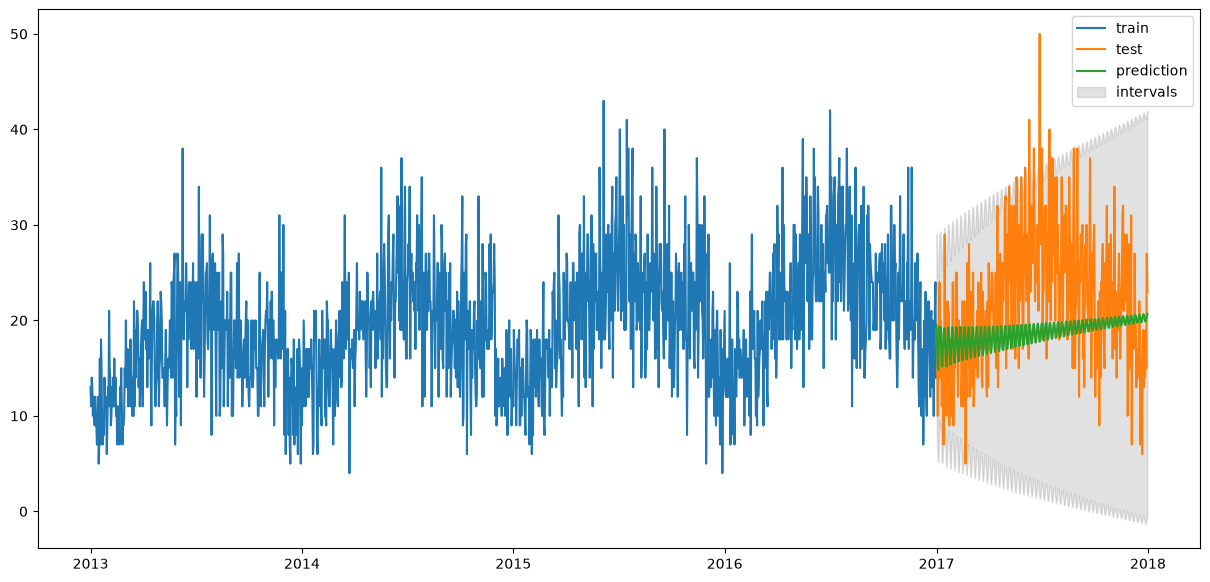

In [22]:
plot_results(data_train, data_test, y_arima_forecast, plot_conf_int=True,
             left_bound=conf_int.T[0],
             right_bound=conf_int.T[1])

In [23]:
compare_table = add_method_comparison('Auto arima model', data_test, y_arima_forecast, compare_table)
compare_table

,method,MSE,MAE,MAPE
0,Prophet,24.681231,4.032162,22.234017
1,Prophet + US holidays,25.021806,4.068062,22.477414
2,Prophet + Box-Cox,24.110664,3.987201,21.678861
3,Auto arima model,57.184355,5.920435,27.376840


### 5.2. AutoARIMA exog

In [24]:
# Более компактные календарные exog-признаки для AutoARIMA/SARIMAX

exog = pd.DataFrame(index=data.index)

# Годовая сезонность
exog['sin365'] = np.sin(2 * np.pi * exog.index.dayofyear / 365.25)
exog['cos365'] = np.cos(2 * np.pi * exog.index.dayofyear / 365.25)

# Недельная сезонность через sin/cos,
# вместо one-hot по дням недели
exog['sin7'] = np.sin(2 * np.pi * exog.index.dayofweek / 7)
exog['cos7'] = np.cos(2 * np.pi * exog.index.dayofweek / 7)

# Месячная сезонность
exog['sin30'] = np.sin(2 * np.pi * exog.index.day / 30.5)
exog['cos30'] = np.cos(2 * np.pi * exog.index.day / 30.5)

# Простые бинарные признаки
exog['is_weekend'] = (exog.index.dayofweek >= 5).astype(int)
exog['is_month_start'] = exog.index.is_month_start.astype(int)
exog['is_month_end'] = exog.index.is_month_end.astype(int)

# На всякий случай приводим всё к float,
# чтобы pmdarima/statsmodels не спотыкались о типы
exog = exog.astype(float)

exog_to_train = exog.iloc[:-test_size]
exog_to_test = exog.iloc[-test_size:]

todo: используйте модель `auto_arima` с экзогенными переменными, которые созданы выше (их не надо менять).

Посчитайте метрики качества и добавьте их в датафрейм (сравнительную таблицу) с метриками по всем обученным до этого моделям.

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=9561.239, Time=0.04 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=9115.600, Time=0.84 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=8637.883, Time=1.26 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=9559.240, Time=0.20 sec
 ARIMA(0,1,1)(0,0,0)[7] intercept   : AIC=8644.647, Time=0.46 sec
 ARIMA(0,1,1)(1,0,1)[7] intercept   : AIC=inf, Time=1.57 sec
 ARIMA(0,1,1)(1,0,0)[7] intercept   : AIC=8636.831, Time=0.95 sec
 ARIMA(0,1,0)(1,0,0)[7] intercept   : AIC=9541.132, Time=0.31 sec
 ARIMA(1,1,1)(1,0,0)[7] intercept   : AIC=8638.671, Time=1.41 sec
 ARIMA(0,1,2)(1,0,0)[7] intercept   : AIC=8638.681, Time=1.15 sec
 ARIMA(1,1,2)(1,0,0)[7] intercept   : AIC=8640.813, Time=1.48 sec
 ARIMA(0,1,1)(1,0,0)[7]             : AIC=8635.063, Time=0.48 sec
 ARIMA(0,1,1)(0,0,0)[7]             : AIC=8642.839, Time=0.26 sec
 ARIMA(0,1,1)(1,0,1)[7]             : AIC=inf, Time=1.48 sec
 ARIMA(0,1,1)(0,0,1)[7]             : AIC=8

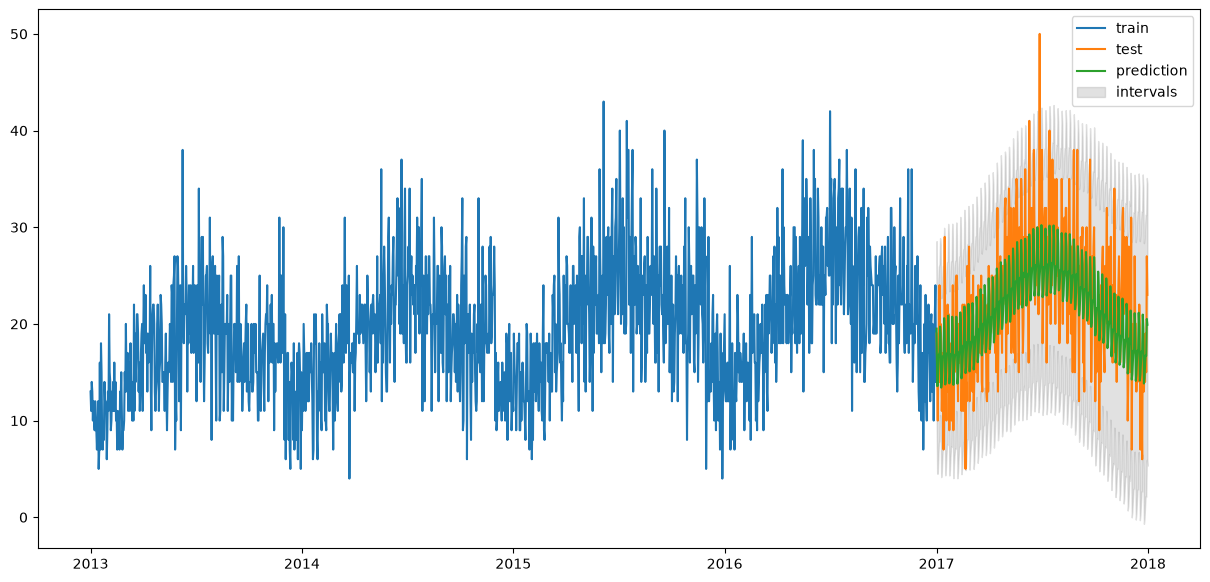

,method,MSE,MAE,MAPE
0,Prophet,24.681231,4.032162,22.234017
1,Prophet + US holidays,25.021806,4.068062,22.477414
2,Prophet + Box-Cox,24.110664,3.987201,21.678861
3,Auto arima model,57.184355,5.920435,27.376840
4,Auto arima exog model,25.151232,3.965786,20.220451


In [25]:
#to do
# AutoARIMA с компактными exog-признаками

arima_exog_model = auto_arima(
    data_train,
    X=exog_to_train,
    seasonal=True,
    m=7,
    start_p=0,
    start_q=0,
    max_p=3,
    max_q=3,
    start_P=0,
    start_Q=0,
    max_P=1,
    max_Q=1,
    d=1,
    D=0,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)

y_arima_exog_forecast, conf_int_exog = arima_exog_model.predict(
    n_periods=test_size,
    X=exog_to_test,
    return_conf_int=True,
    alpha=0.05
)

plot_results(
    data_train,
    data_test,
    y_arima_exog_forecast,
    plot_conf_int=True,
    left_bound=conf_int_exog.T[0],
    right_bound=conf_int_exog.T[1]
)

compare_table = add_method_comparison(
    'Auto arima exog model',
    data_test,
    y_arima_exog_forecast,
    compare_table
)

compare_table

### 6. SARIMAX [without exog]

### 6.1. SARIMAX [without exog]

In [26]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# передаем параметры из прошлой модели
real_sarimax_model = SARIMAX(data_train, order=(3, 1, 5), seasonal_order=(0, 0, 2, 7),
    seasonal_periods=7,
    ).fit()


C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['seasonal_periods']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [27]:
forecast = real_sarimax_model.get_forecast(steps=len(data_test))
y_sarimax_real_forecast = forecast.predicted_mean
conf_int = forecast.conf_int()


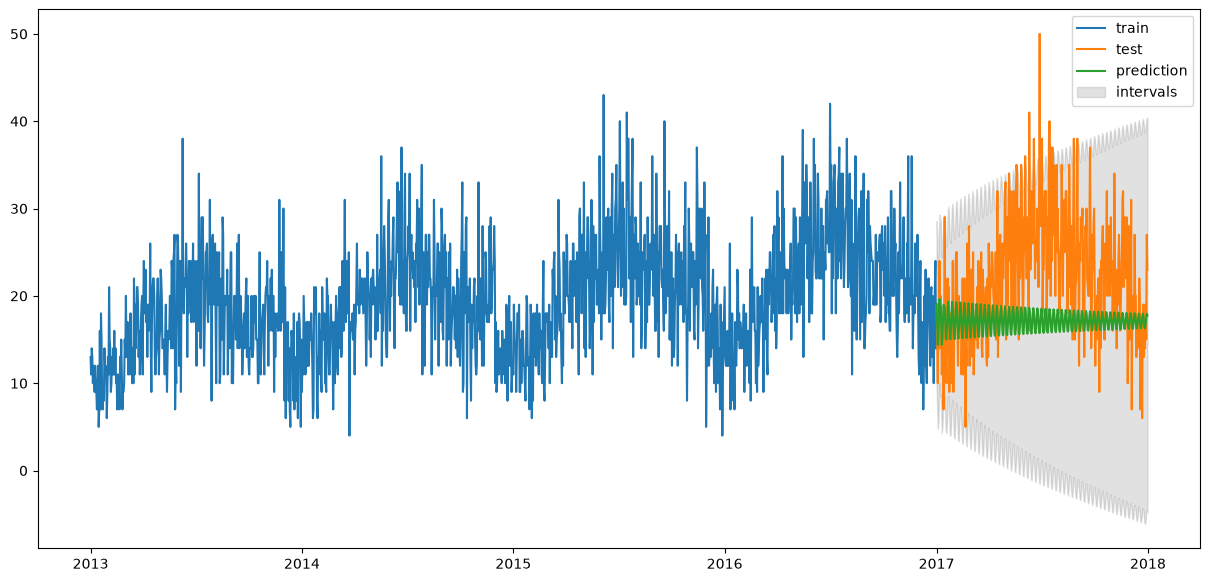

In [28]:
plot_results(data_train, data_test,
             y_sarimax_real_forecast, plot_conf_int=True,
             left_bound=conf_int['lower sales'], right_bound=conf_int['upper sales'])

In [29]:
compare_table = add_method_comparison('Original SARIMAX', data_test, y_sarimax_real_forecast, compare_table)
compare_table

,method,MSE,MAE,MAPE
0,Prophet,24.681231,4.032162,22.234017
1,Prophet + US holidays,25.021806,4.068062,22.477414
2,Prophet + Box-Cox,24.110664,3.987201,21.678861
3,Auto arima model,57.184355,5.920435,27.376840
4,Auto arima exog model,25.151232,3.965786,20.220451
5,Original SARIMAX,70.672355,6.640773,28.847513


### 6.2. SARIMAX with exog

In [30]:
# Более компактные календарные exog-признаки для AutoARIMA/SARIMAX

exog = pd.DataFrame(index=data.index)

# Годовая сезонность
exog['sin365'] = np.sin(2 * np.pi * exog.index.dayofyear / 365.25)
exog['cos365'] = np.cos(2 * np.pi * exog.index.dayofyear / 365.25)

# Недельная сезонность через sin/cos,
# вместо one-hot по дням недели
exog['sin7'] = np.sin(2 * np.pi * exog.index.dayofweek / 7)
exog['cos7'] = np.cos(2 * np.pi * exog.index.dayofweek / 7)

# Месячная сезонность
exog['sin30'] = np.sin(2 * np.pi * exog.index.day / 30.5)
exog['cos30'] = np.cos(2 * np.pi * exog.index.day / 30.5)

# Простые бинарные признаки
exog['is_weekend'] = (exog.index.dayofweek >= 5).astype(int)
exog['is_month_start'] = exog.index.is_month_start.astype(int)
exog['is_month_end'] = exog.index.is_month_end.astype(int)

# На всякий случай приводим всё к float,
# чтобы pmdarima/statsmodels не спотыкались о типы
exog = exog.astype(float)

exog_to_train = exog.iloc[:-test_size]
exog_to_test = exog.iloc[-test_size:]

todo: используйте модель `SARIMAX` с экзогенными переменными, которые созданы выше (их не надо менять), для улучшения предсказаний.

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


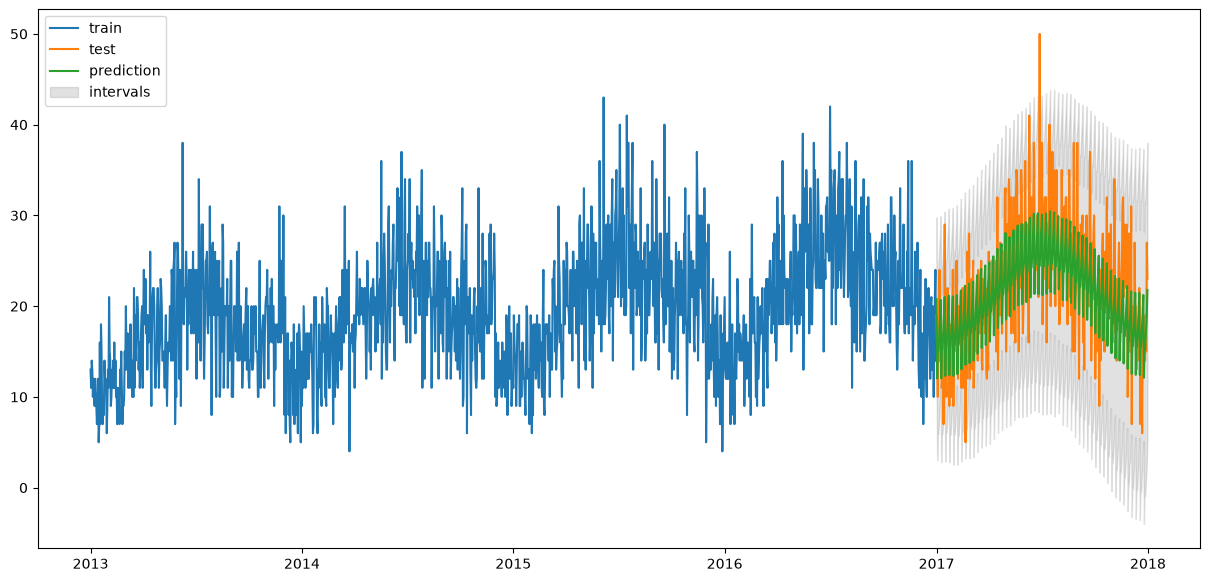

,method,MSE,MAE,MAPE
0,Prophet,24.681231,4.032162,22.234017
1,Prophet + US holidays,25.021806,4.068062,22.477414
2,Prophet + Box-Cox,24.110664,3.987201,21.678861
3,Auto arima model,57.184355,5.920435,27.376840
4,Auto arima exog model,25.151232,3.965786,20.220451
5,Original SARIMAX,70.672355,6.640773,28.847513
6,SARIMAX exog model,24.961659,3.976742,20.079416


In [31]:
#to do
# SARIMAX с экзогенными переменными

from statsmodels.tsa.statespace.sarimax import SARIMAX

# Обучаем SARIMAX на train-части ряда
# order и seasonal_order берём близкими к тем, что использовались выше
# exog=exog_to_train добавляет внешние признаки сезонности
sarimax_exog_model = SARIMAX(
    data_train,
    exog=exog_to_train,
    order=(3, 1, 5),
    seasonal_order=(0, 0, 2, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit()

# Строим прогноз на test_size шагов вперёд
# Для будущего периода обязательно передаём exog_to_test,
# иначе модель не будет знать значения внешних признаков для тестовых дат
forecast_exog = sarimax_exog_model.get_forecast(
    steps=len(data_test),
    exog=exog_to_test
)

# Среднее прогнозное значение
y_sarimax_exog_forecast = forecast_exog.predicted_mean

# Доверительный интервал прогноза
conf_int_exog = forecast_exog.conf_int()

# Строим график train/test/prediction/intervаls
plot_results(
    data_train,
    data_test,
    y_sarimax_exog_forecast,
    plot_conf_int=True,
    left_bound=conf_int_exog.iloc[:, 0],
    right_bound=conf_int_exog.iloc[:, 1]
)

# Добавляем метрики SARIMAX with exog в общую таблицу
compare_table = add_method_comparison(
    'SARIMAX exog model',
    data_test,
    y_sarimax_exog_forecast,
    compare_table
)

compare_table

In [32]:
!pip install scikit-learn==1.5.2

Defaulting to user installation because normal site-packages is not writeable


### 7. TBATS

Модель учитывает несколько сезонностей, но не может принимать экзогенные признаки.

In [33]:
tbats_estimator = TBATS(
    seasonal_periods=[7, 365.25],
    n_jobs=1
)

model = tbats_estimator.fit(data_train)

In [34]:
print(model.summary())

Use Box-Cox: True
Use trend: False
Use damped trend: False
Seasonal periods: [  7.   365.25]
Seasonal harmonics [ 3 11]
ARMA errors (p, q): (0, 0)
Box-Cox Lambda 0.234872
Smoothing (Alpha): 0.015826
Seasonal Parameters (Gamma): [ 8.45253427e-04  1.56715257e-03 -1.81753722e-03 -2.62143396e-05]
AR coefficients []
MA coefficients []
Seed vector [ 3.81266216e+00 -2.74648613e-01 -1.69626706e-02  1.26128649e-01
 -5.67943208e-02  1.86124140e-01  1.01120484e-01 -5.00491904e-01
 -5.29880912e-02 -1.14034258e-01 -5.71844636e-03 -4.67509612e-02
  2.10869447e-05  3.17363236e-02  2.56748325e-02  4.95178399e-02
  3.09192598e-02  3.19081591e-02 -6.20532742e-02 -1.00282454e-01
 -7.52740164e-02  2.34408598e-02  6.82534165e-02  7.30938911e-02
  9.59124949e-03  1.53375444e-02 -1.72073394e-02 -3.43625894e-02
 -4.08393025e-03]

AIC 14974.878053


In [35]:
tbats_forecast, confidence_info = model.forecast(steps=365, confidence_level=0.95)

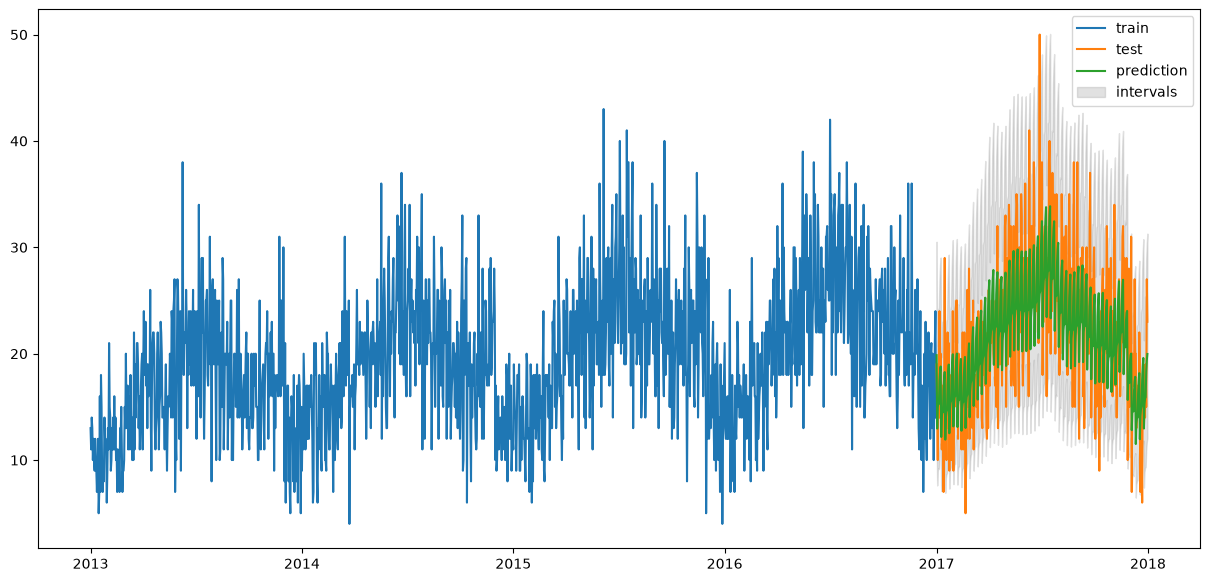

In [36]:
plot_results(data_train, data_test, tbats_forecast, plot_conf_int=True,
             left_bound=confidence_info['lower_bound'],
             right_bound=confidence_info['upper_bound'])

In [37]:
final_table = add_method_comparison('TBATS model', data_test, tbats_forecast, compare_table)

In [38]:
final_table

,method,MSE,MAE,MAPE
0,Prophet,24.681231,4.032162,22.234017
1,Prophet + US holidays,25.021806,4.068062,22.477414
2,Prophet + Box-Cox,24.110664,3.987201,21.678861
3,Auto arima model,57.184355,5.920435,27.376840
4,Auto arima exog model,25.151232,3.965786,20.220451
5,Original SARIMAX,70.672355,6.640773,28.847513
6,SARIMAX exog model,24.961659,3.976742,20.079416
7,TBATS model,23.633498,3.856241,19.786564


### 8. ИТОГО

todo:
- Опишите, что вы сделали в этой работе, какие параметры моделей подбирали и как.
- Сравните модели между собой и проанализируйте результаты.
- Выберите лучшую модель.

Метрика MAPE, которую нужно достичь (достаточно правильной настройки гиперпараметров моделей), должна быть менее 20%.

In [39]:
final_table

,method,MSE,MAE,MAPE
0,Prophet,24.681231,4.032162,22.234017
1,Prophet + US holidays,25.021806,4.068062,22.477414
2,Prophet + Box-Cox,24.110664,3.987201,21.678861
3,Auto arima model,57.184355,5.920435,27.376840
4,Auto arima exog model,25.151232,3.965786,20.220451
5,Original SARIMAX,70.672355,6.640773,28.847513
6,SARIMAX exog model,24.961659,3.976742,20.079416
7,TBATS model,23.633498,3.856241,19.786564


## Вывод

В работе был рассмотрен временной ряд дневных продаж для товара item = 1 в магазине store = 1. Данные были разделены на обучающую и тестовую выборки: последние 365 дней были отложены в тест.

Для прогнозирования были обучены несколько моделей: Prophet, Prophet с учётом праздников США, Prophet с преобразованием Бокса — Кокса, AutoARIMA, AutoARIMA с экзогенными признаками, SARIMAX, SARIMAX с экзогенными признаками и TBATS.

Качество моделей оценивалось по метрикам MSE, MAE и MAPE. Основной метрикой для выбора лучшей модели была MAPE, так как она показывает среднюю ошибку прогноза в процентах.

Базовый Prophet показал MAPE 22.23. Добавление праздников США не улучшило качество: MAPE составила 22.48. Преобразование Бокса — Кокса немного улучшило Prophet: MAPE снизилась до 21.68.

Лучший результат показала модель TBATS с учётом нескольких сезонностей, включая недельную и годовую сезонность. Её MAPE составила 19.79, что ниже требуемого порога 20%.

Таким образом, лучшей моделью по итогам экспериментов стала TBATS. Она лучше остальных моделей описала сезонную структуру ряда и позволила достичь требуемого качества прогноза.